## Implementando uma MLP com Torch

In [1]:
import torch
import numpy as np

In [4]:

class Mlp(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.act_fn = torch.nn.LeakyReLU()
        self._hidden_1 = torch.nn.Linear(1, 16)
        self._hidden_2 = torch.nn.Linear(16, 16)
        self._out = torch.nn.Linear(16, 1)

    def forward(self, x):
        h1 = self._hidden_1(x)
        h1 = self.act_fn(h1)

        h2 = self._hidden_2(h1)
        h2 = self.act_fn(h2)

        y = self._out(h2)

        return y


mlp = Mlp()
x = torch.tensor([[1.0]], dtype=torch.float32)
mlp.forward(x)


tensor([[-0.1092]], grad_fn=<AddmmBackward0>)

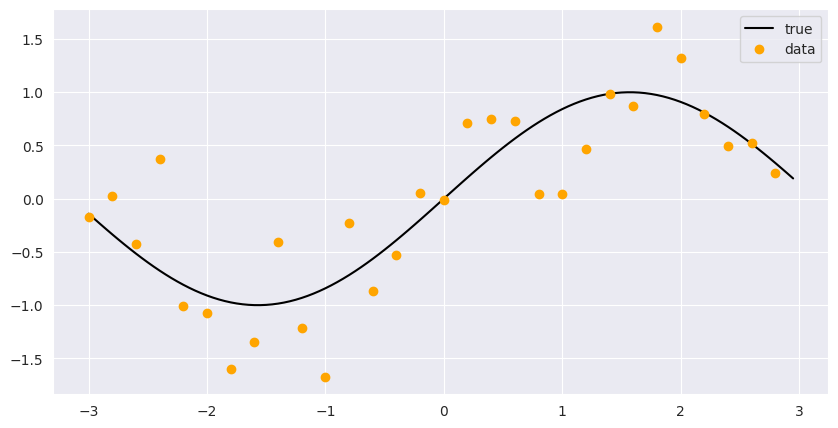

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

x = np.arange(-3.0, 3.0, 0.2)
y = np.sin(x)
y += np.random.normal(size=y.shape) * 0.4

# dados apenas para plotar com mais suavidade
all_x = np.arange(-3.0, 3.0, 0.05)
all_y = np.sin(all_x)

plt.close('all')
plt.figure(figsize=(10, 5))
plt.plot(all_x, all_y, '-', color='black', label='true')
plt.plot(x, y, 'o', color='orange', label='data')
plt.legend()
plt.show()

In [8]:

mlp = Mlp()

x_ts = torch.tensor(x, dtype=torch.float32).reshape(-1, 1, 1)
y_ts = torch.tensor(y, dtype=torch.float32).reshape(-1, 1, 1)

params = mlp.parameters()
loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(params, lr=0.001)

for epoch in range(10000):
    opt.zero_grad()
    prd_y = mlp.forward(x_ts)
    loss = loss_fn(y_ts, prd_y)
    loss.backward()
    opt.step()

    print(loss.item())


0.7660102844238281
0.7570057511329651
0.7479712963104248
0.7390355467796326
0.7303066253662109
0.721563994884491
0.7128667235374451
0.7042664289474487
0.6957563757896423
0.6874476075172424
0.6793302297592163
0.6712488532066345
0.6633086800575256
0.6554001569747925
0.6475868225097656
0.6398214101791382
0.6321146488189697
0.6245235204696655
0.6170787215232849
0.6097956299781799
0.602704644203186
0.5957252979278564
0.5889282822608948
0.58231121301651
0.5758028030395508
0.5693514347076416
0.5629685521125793
0.5566832423210144
0.5505316257476807
0.5444170832633972
0.538379430770874
0.5324904322624207
0.5267007350921631
0.520938515663147
0.5151870250701904
0.509480357170105
0.503818929195404
0.4982505738735199
0.49275705218315125
0.4873031973838806
0.481876015663147
0.4764910340309143
0.4710944592952728
0.46570253372192383
0.460359662771225
0.4550786316394806
0.4498398005962372
0.4446393847465515
0.4394744038581848
0.43435588479042053
0.4292868971824646
0.4242704212665558
0.4192609488964081


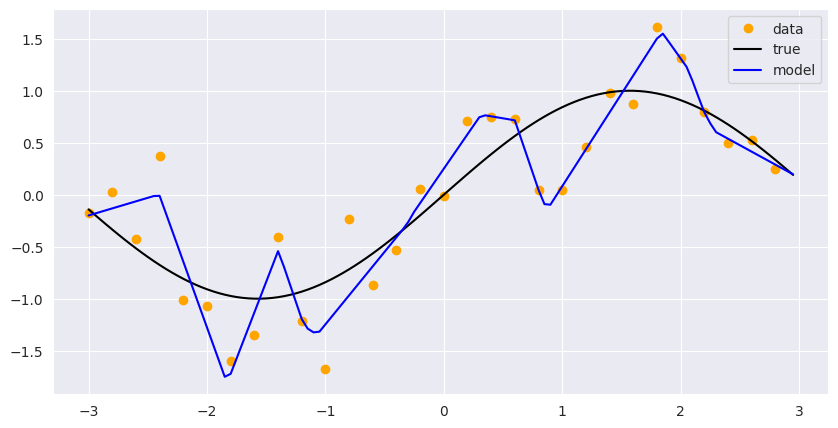

In [9]:
# dados apenas para plotar com mais suavidade
all_x = np.arange(-3.0, 3.0, 0.05)
all_y = np.sin(all_x)

prd_y = []

with torch.no_grad():
  for x_i in all_x:
    x_i = torch.tensor(x_i, dtype=torch.float32).reshape(1, 1)
    y_i = mlp.forward(x_i).detach().numpy().squeeze()
    prd_y.append(y_i)

plt.close('all')
plt.figure(figsize=(10, 5))
plt.plot(x, y, 'o', color='orange', label='data')
plt.plot(all_x, all_y, '-', color='black', label='true')
plt.plot(all_x, prd_y, '-', color='blue', label='model')
plt.legend()
plt.show()

Usando a `tanh` como função de ativação.

In [15]:

np.random.seed(1)
mlp = Mlp(tanh)
loss_fn = NeuralSinRegLossFn(mlp)
params = mlp.parameters()
history = gd(loss_fn, 3000, 1e-1, params)
results['reg-nn-tanh'] = history

[[0.64213178]]
[[0.06429985]]
[[0.03874641]]
[[0.03652965]]
[[0.03516874]]
[[0.03413861]]
[[0.03334055]]
[[0.03271227]]
[[0.03221036]]
[[0.03180353]]
[[0.03146891]]
[[0.0311897]]
[[0.03095348]]
[[0.03075098]]
[[0.03057529]]
[[0.03042116]]
[[0.03028458]]
[[0.03016247]]
[[0.03005242]]
[[0.02995254]]


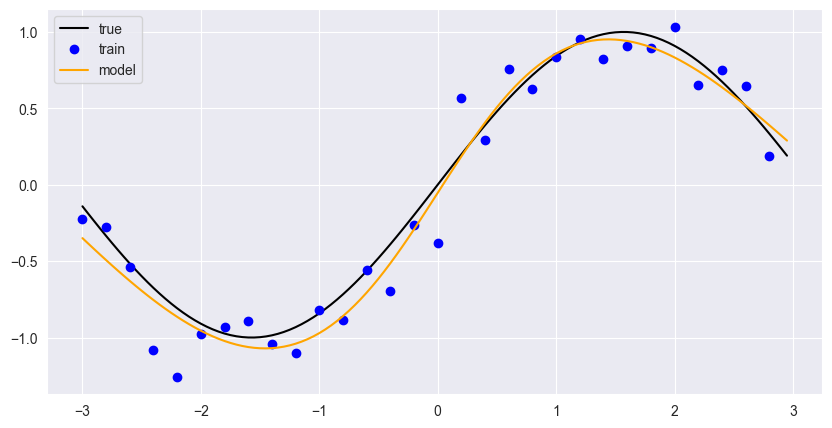

In [16]:
# dados apenas para plotar com mais suavidade
all_x = np.arange(-3.0, 3.0, 0.05)
all_y = np.sin(all_x)

prd_y = [mlp.forward(x_i).numpy().squeeze() for x_i in all_x]

plt.close('all')
plt.figure(figsize=(10, 5))
plt.plot(all_x, all_y, '-', color='black', label='true')
plt.plot(loss_fn.x, loss_fn.y, 'o', color='blue', label='train')
plt.plot(all_x, prd_y, '-', color='orange', label='model')
plt.legend()
plt.show()

Usando a sigmoide.

In [17]:

np.random.seed(1)
mlp = Mlp(sigmoid)
loss_fn = NeuralSinRegLossFn(mlp)
params = mlp.parameters()
history = gd(loss_fn, 3000, 7e-1, params)
results['reg-nn-sigmoid'] = history

[[0.61286181]]
[[0.13933899]]
[[0.0890533]]
[[0.06184236]]
[[0.0515937]]
[[0.04756851]]
[[0.04563713]]
[[0.04439965]]
[[0.04341436]]
[[0.04254533]]
[[0.04174883]]
[[0.0410142]]
[[0.04034116]]
[[0.03972749]]
[[0.03916814]]
[[0.03865725]]
[[0.03818912]]
[[0.03775854]]
[[0.03736089]]
[[0.0369924]]


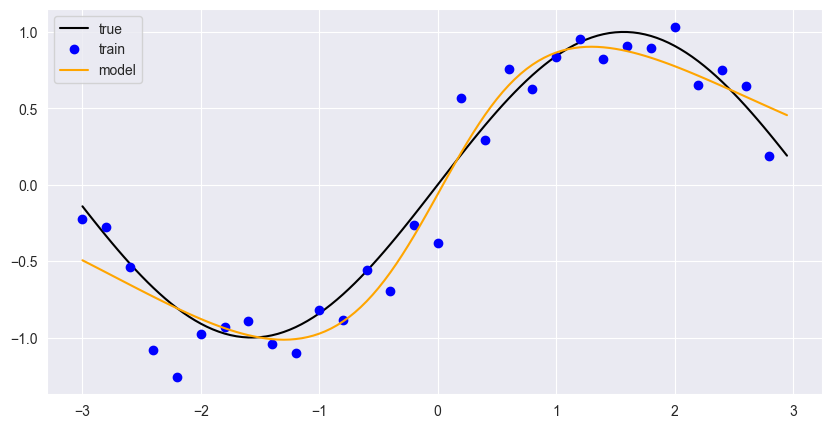

In [18]:
# dados apenas para plotar com mais suavidade
all_x = np.arange(-3.0, 3.0, 0.05)
all_y = np.sin(all_x)

prd_y = [mlp.forward(x_i).numpy().squeeze() for x_i in all_x]

plt.close('all')
plt.figure(figsize=(10, 5))
plt.plot(all_x, all_y, '-', color='black', label='true')
plt.plot(loss_fn.x, loss_fn.y, 'o', color='blue', label='train')
plt.plot(all_x, prd_y, '-', color='orange', label='model')
plt.legend()
plt.show()

In [19]:
import pickle

with open("data.pkl", "wb") as f:
    pickle.dump(results, f)